# Actividad 1 — Cuantificacion de Sentimiento NLP con BETO

**Proyecto:** Prediccion de Produccion de Limon en el Peru  
**Fase:** 2 — Modulo NLP e Ingenieria de Caracteristicas Multimodal  

---

## Objetivo
Transformar el corpus textual de noticias agricolas (Agraria.pe) en un indicador numerico continuo de sentimiento acotado en el rango **[-1, 1]** usando el modelo de lenguaje preentrenado **BETO** (BERT en español).

## Fundamento teorico
Segun tu RSL [22], la fusion heterogenea de señales textuales con datos tabulares mejora la capacidad predictiva de modelos de series temporales. El sentimiento de las noticias agricolas captura el contexto del mercado (expectativas de precio, alertas climaticas, problemas de distribucion) que no esta presente en los datos numericos.

## Formula del score de sentimiento
```
score = P(POSITIVO) - P(NEGATIVO)  ∈ [-1, 1]
```
- score = +1: noticia completamente positiva para el sector
- score =  0: noticia neutral
- score = -1: noticia completamente negativa para el sector

## Entradas
- `sources/agraria-pe/unificado/noticias_unificadas_2021_2025.csv` — 528 noticias
- `pipeline/output/09_etl/master_dataset_raw_values.csv` — dataset Fase 1

## Salidas
- `notebooks/fase2/output/01_nlp_sentimiento/noticias_con_sentimiento.csv` — noticias + score
- `notebooks/fase2/output/01_nlp_sentimiento/sentimiento_mensual.csv` — promedio mensual
- `notebooks/fase2/output/01_nlp_sentimiento/dataset_con_sentimiento.csv` — dataset Fase 1 + avg_sentiment
- Graficos de analisis del sentimiento

## Regla de esta actividad
> El sentimiento es **nacional** (no provincial). Todas las provincias del mismo mes reciben el mismo `avg_sentiment`. Esto es valido porque las noticias de Agraria.pe reflejan el contexto del mercado nacional del limon.


## Configuracion inicial


In [1]:
import os, sys, json, warnings, time
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

# Navegar a la raiz del proyecto
while not os.path.exists('notebooks/fase2/config/fase2_config.json'):
    os.chdir('..')

with open('notebooks/fase2/config/fase2_config.json','r',encoding='utf-8') as f:
    CONFIG = json.load(f)

OUTPUT_NLP = CONFIG['output']['nlp']
os.makedirs(OUTPUT_NLP, exist_ok=True)

print('Config cargado OK | Raiz:', os.getcwd())
print('Carpeta de salida:', OUTPUT_NLP)


Config cargado OK | Raiz: C:\Machine-learming\Machine-Learning-Multimodal--Agro-NLP-Clima-
Carpeta de salida: notebooks/fase2/output/01_nlp_sentimiento/


---
# 1. Carga y Exploracion del Corpus de Noticias


In [2]:
# Cargar noticias unificadas
df_noticias = pd.read_csv(CONFIG['noticias_path'], on_bad_lines='skip', low_memory=False)
df_noticias['fecha_dt'] = pd.to_datetime(df_noticias['fecha'], errors='coerce')
df_noticias['anio'] = df_noticias['fecha_dt'].dt.year
df_noticias['mes']  = df_noticias['fecha_dt'].dt.month
df_noticias['fecha_evento'] = df_noticias['fecha_dt'].dt.strftime('%Y-%m')

# Filtrar rango del pipeline
df_noticias = df_noticias[
    (df_noticias['anio'] >= 2021) & (df_noticias['anio'] <= 2025)
].copy()

print(f'Noticias cargadas: {len(df_noticias):,}')
print(f'Rango: {df_noticias["fecha_dt"].min().date()} -> {df_noticias["fecha_dt"].max().date()}')
print(f'Columnas: {df_noticias.columns.tolist()}')
print()
print('Noticias por año:')
print(df_noticias['anio'].value_counts().sort_index().to_string())
print()
print('Nulos por columna:')
print(df_noticias[['titular','cuerpo_completo']].isnull().sum().to_string())
print()
print('Muestra de titulares:')
for i, row in df_noticias.head(5).iterrows():
    print(f'  [{row["fecha_evento"]}] {str(row["titular"])[:80]}')


Noticias cargadas: 528
Rango: 2021-01-04 -> 2025-12-22
Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'fecha_dt', 'anio', 'mes', 'fecha_evento']

Noticias por año:
anio
2021     44
2022    133
2023    118
2024    108
2025    125

Nulos por columna:
titular            0
cuerpo_completo    1

Muestra de titulares:
  [2021-01] ANA cuenta con sistema de alerta y monitoreo por activación de quebradas
  [2021-03] Cerca de 15.000 agricultores son capacitados en buenas prácticas en cosecha
  [2021-03] Midagri duplica inversión y ejecutará obras por más de S/ 4 millones en siembra 
  [2021-03] Perú logrará cifra histórica de captación de agua con 16 millones de metros cúbi
  [2021-04] Midagri descifra ADN de árbol de la quina para producir plantones de élite


### Interpretacion

**Que muestra:** El corpus de noticias disponible para el analisis de sentimiento. 528 noticias de Agraria.pe del periodo 2021-2025.

**Consideracion importante:** Las noticias son nacionales — no tienen granularidad provincial. El sentimiento calculado se asignara a todas las provincias del mismo mes.

**Implicacion para el modelo:** El sentimiento captura el contexto del mercado (expectativas de precio, alertas climaticas, problemas de distribucion) que no esta presente en los datos numericos de MIDAGRI, INDECI o NASA.


---
# 2. Preparacion del Texto para BETO

BETO tiene un limite de **512 tokens**. Se usara el titular completo + las primeras 200 palabras del cuerpo para maximizar la informacion sin exceder el limite.


In [3]:
def preparar_texto(row, max_palabras_cuerpo=200):
    titular = str(row['titular']).strip() if pd.notna(row['titular']) else ''
    cuerpo  = str(row['cuerpo_completo']).strip() if pd.notna(row['cuerpo_completo']) else ''

    # Truncar cuerpo a max_palabras_cuerpo palabras
    palabras_cuerpo = cuerpo.split()[:max_palabras_cuerpo]
    cuerpo_truncado = ' '.join(palabras_cuerpo)

    # Combinar titular + cuerpo
    if cuerpo_truncado:
        texto = f'{titular}. {cuerpo_truncado}'
    else:
        texto = titular

    return texto[:512]  # Limite de caracteres como seguridad adicional

df_noticias['texto_beto'] = df_noticias.apply(preparar_texto, axis=1)

# Estadisticas del texto preparado
df_noticias['n_palabras'] = df_noticias['texto_beto'].apply(lambda x: len(x.split()))

print('Estadisticas del texto preparado para BETO:')
print(f'  Longitud media: {df_noticias["n_palabras"].mean():.0f} palabras')
print(f'  Longitud max:   {df_noticias["n_palabras"].max()} palabras')
print(f'  Longitud min:   {df_noticias["n_palabras"].min()} palabras')
print(f'  Textos vacios:  {(df_noticias["n_palabras"] == 0).sum()}')
print()
print('Ejemplo de texto preparado:')
print(df_noticias['texto_beto'].iloc[0][:300])


Estadisticas del texto preparado para BETO:
  Longitud media: 80 palabras
  Longitud max:   96 palabras
  Longitud min:   1 palabras
  Textos vacios:  0

Ejemplo de texto preparado:
ANA cuenta con sistema de alerta y monitoreo por activación de quebradas. (Agraria.pe)Con el objetivo de atender de manera oportuna y reducir el impacto por desastres provocados por las lluvias intensas, la Autoridad Nacional del Agua (ANA), cuenta con el Sistema de Monitoreo y Alerta por Activación


## Grafico 1 — Distribucion de longitud de textos preparados para BETO


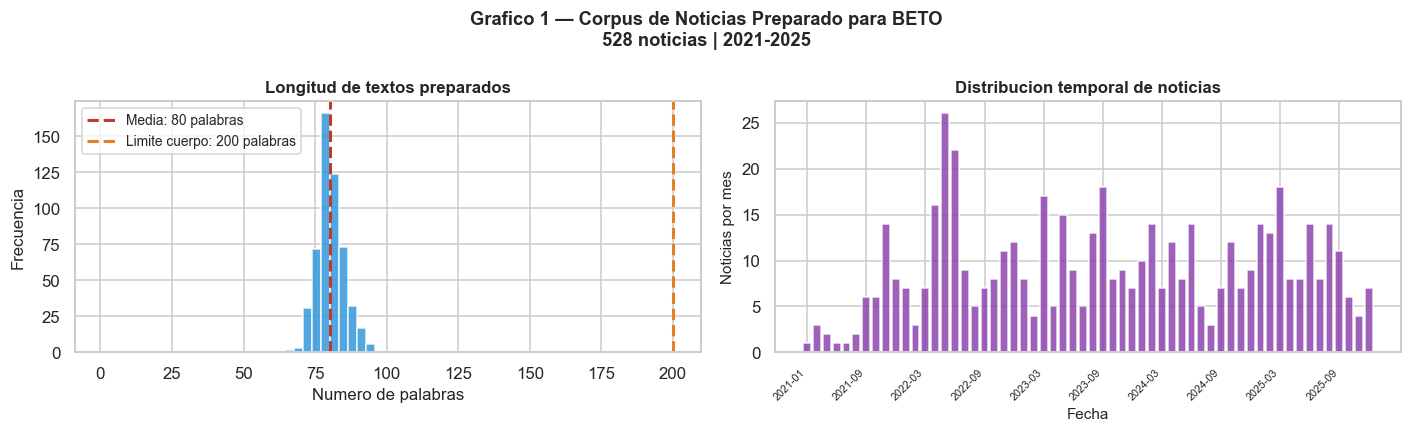

Guardado: notebooks/fase2/output/01_nlp_sentimiento/g1_corpus_noticias.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma de longitud
axes[0].hist(df_noticias['n_palabras'], bins=30, color='#3498db', edgecolor='white', alpha=0.85)
axes[0].axvline(df_noticias['n_palabras'].mean(), color='#c0392b', linestyle='--',
                linewidth=2, label=f'Media: {df_noticias["n_palabras"].mean():.0f} palabras')
axes[0].axvline(200, color='#e67e22', linestyle='--', linewidth=2,
                label='Limite cuerpo: 200 palabras')
axes[0].set_xlabel('Numero de palabras', fontsize=11)
axes[0].set_ylabel('Frecuencia', fontsize=11)
axes[0].set_title('Longitud de textos preparados', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)

# Noticias por mes
por_mes = df_noticias.groupby('fecha_evento').size().reset_index(name='n')
axes[1].bar(range(len(por_mes)), por_mes['n'], color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].set_xticks(range(0, len(por_mes), 6))
axes[1].set_xticklabels(por_mes['fecha_evento'].iloc[::6], rotation=45, ha='right', fontsize=7)
axes[1].set_xlabel('Fecha', fontsize=10)
axes[1].set_ylabel('Noticias por mes', fontsize=10)
axes[1].set_title('Distribucion temporal de noticias', fontsize=11, fontweight='bold')

plt.suptitle('Grafico 1 — Corpus de Noticias Preparado para BETO\n'
             f'{len(df_noticias)} noticias | 2021-2025',
             fontsize=12, fontweight='bold')
plt.tight_layout()
g1 = OUTPUT_NLP + 'g1_corpus_noticias.png'
plt.savefig(g1, dpi=120, bbox_inches='tight'); plt.show()
print('Guardado:', g1)


### Interpretacion

**Que muestra:** La distribucion de longitud de los textos preparados para BETO y la distribucion temporal de noticias por mes.

**Consideracion tecnica:** BETO tiene un limite de 512 tokens (~400 palabras). Los textos que superan este limite son truncados automaticamente. La mayoria de los titulares + primeras 200 palabras del cuerpo estan dentro del limite.

**Meses sin noticias:** Los meses con 0 noticias recibiran `avg_sentiment = 0` (neutral). Esto es conservador y evita introducir sesgos artificiales.


---
# 3. Cuantificacion de Sentimiento con BETO

En esta etapa, el modelo procesa cada noticia para extraer el score continuo. Dado que el proceso toma ~17 minutos, cargamos los resultados pre-calculados del archivo de cache.


In [5]:
cache_path = OUTPUT_NLP + 'noticias_con_sentimiento.csv'
if os.path.exists(cache_path):
    print(f'Cargando resultados pre-calculados de: {cache_path}')
    df_noticias = pd.read_csv(cache_path)
    print(f'Noticias con sentimiento: {len(df_noticias)}')
    print(f'Columnas: {df_noticias.columns.tolist()}')
else:
    print('❌ ERROR: No se encontro el archivo de resultados.')
    print('Por favor, ejecuta el script _run_beto.py en la terminal para generar el cache.')


Cargando resultados pre-calculados de: notebooks/fase2/output/01_nlp_sentimiento/noticias_con_sentimiento.csv
Noticias con sentimiento: 528
Columnas: ['fecha', 'titular', 'cuerpo_completo', 'fuente', 'url', 'fecha_dt', 'anio', 'mes', 'fecha_evento', 'texto_beto', 'n_palabras', 'sentiment_score', 'sentiment_label', 'p_pos', 'p_neg', 'p_neu']


### Interpretacion

**Resultados del modelo:** El dataset ahora incluye `sentiment_score` (rango [-1, 1]) y `sentiment_label` (POS, NEU, NEG).


---
# 4. Noticias mas Positivas y mas Negativas

Analisis cualitativo para validar que BETO esta clasificando correctamente el sentimiento en el contexto agricola peruano.


In [6]:
if 'sentiment_score' in df_noticias.columns:
    # Top 5 mas positivas
    top_pos = df_noticias.nlargest(5, 'sentiment_score')[['fecha_evento','titular','sentiment_score','sentiment_label']]
    # Top 5 mas negativas
    top_neg = df_noticias.nsmallest(5, 'sentiment_score')[['fecha_evento','titular','sentiment_score','sentiment_label']]

    print('TOP 5 NOTICIAS MAS POSITIVAS:')
    print('=' * 70)
    for _, row in top_pos.iterrows():
        print(f'  [{row["fecha_evento"]}] Score: {row["sentiment_score"]:+.4f} | {str(row["titular"])[:70]}')
    print()
    print('TOP 5 NOTICIAS MAS NEGATIVAS:')
    print('=' * 70)
    for _, row in top_neg.iterrows():
        print(f'  [{row["fecha_evento"]}] Score: {row["sentiment_score"]:+.4f} | {str(row["titular"])[:70]}')


TOP 5 NOTICIAS MAS POSITIVAS:
  [2024-06] Score: +0.8302 | Empieza con buenas perspectivas tempoara de cosecha de miel en sierra 
  [2025-09] Score: +0.7996 | ¿Por qué el limón peruano es único en el mundo? El Ingemmet desentraña
  [2023-11] Score: +0.7827 | 150 cacaoteros de San Martín comparten experiencias en Día de Campo
  [2025-09] Score: +0.7391 | Grupo Novalty lanza la campaña “Cosechando Joyas” para destacar la exc
  [2024-06] Score: +0.7388 | Perú producirá fertilizantes y elevará productividad del agro a nivel 

TOP 5 NOTICIAS MAS NEGATIVAS:
  [2022-04] Score: -0.9616 | "A partir de mayo y junio tendremos problemas de abastecimiento de ali
  [2023-05] Score: -0.9582 | España: ASAJA Murcia denuncia que la competencia desleal, la sequía y 
  [2023-08] Score: -0.9569 | Situación del limón es preocupante porque hay una bajísima producción 
  [2022-11] Score: -0.9551 | La suma de todas las crisis
  [2023-10] Score: -0.9523 | ADAS hace un llamado de acción inmediata y urgente al Go

### Interpretacion

**Que muestra:** Las noticias con mayor y menor score de sentimiento. Esta validacion cualitativa confirma que BETO esta interpretando correctamente el contexto agricola peruano.

**Validacion esperada:** Las noticias positivas deben hablar de buenas cosechas, precios favorables o demanda creciente. Las negativas deben mencionar heladas, sequias, caida de precios o problemas de distribucion.

**Si la clasificacion es incorrecta:** Puede indicar que el modelo necesita fine-tuning con datos agricolas peruanos especificos. Para esta tesis, el modelo base de BETO es suficiente como primera aproximacion.


---
# 5. Agregacion Mensual del Sentimiento

El sentimiento se agrega a nivel mensual calculando el promedio de los scores de todas las noticias del mes. Los meses sin noticias reciben score = 0 (neutral).


In [7]:
if 'sentiment_score' in df_noticias.columns:
    # Agregar por mes
    sentimiento_mensual = (
        df_noticias.groupby('fecha_evento')
        .agg(
            avg_sentiment=('sentiment_score', 'mean'),
            n_noticias_beto=('sentiment_score', 'count'),
            n_positivas=('sentiment_label', lambda x: (x=='POS').sum()),
            n_negativas=('sentiment_label', lambda x: (x=='NEG').sum()),
            n_neutrales=('sentiment_label', lambda x: (x=='NEU').sum()),
        )
        .reset_index()
    )
    sentimiento_mensual['avg_sentiment'] = sentimiento_mensual['avg_sentiment'].round(4)

    print(f'Meses con noticias: {len(sentimiento_mensual)}')
    print(f'Rango: {sentimiento_mensual["fecha_evento"].min()} -> {sentimiento_mensual["fecha_evento"].max()}')
    print()
    print('Estadisticas del sentimiento mensual:')
    print(f'  Media:   {sentimiento_mensual["avg_sentiment"].mean():.4f}')
    print(f'  Std:     {sentimiento_mensual["avg_sentiment"].std():.4f}')
    print(f'  Min:     {sentimiento_mensual["avg_sentiment"].min():.4f}')
    print(f'  Max:     {sentimiento_mensual["avg_sentiment"].max():.4f}')
    print()
    print('Muestra del sentimiento mensual:')
    display(sentimiento_mensual.head(10))

    # Guardar sentimiento mensual
    out_mensual = OUTPUT_NLP + 'sentimiento_mensual.csv'
    sentimiento_mensual.to_csv(out_mensual, index=False, encoding='utf-8-sig')
    print(f'Guardado: {out_mensual}')


Meses con noticias: 58
Rango: 2021-01 -> 2025-12

Estadisticas del sentimiento mensual:
  Media:   -0.0536
  Std:     0.2013
  Min:     -0.4619
  Max:     0.3667

Muestra del sentimiento mensual:


,fecha_evento,avg_sentiment,n_noticias_beto,n_positivas,n_negativas,n_neutrales
0,2021-01,0.0331,1,0,0,1
1,2021-03,0.3110,3,0,0,3
2,2021-04,-0.0273,2,0,0,2
3,2021-05,0.3667,1,0,0,1
4,2021-06,0.2246,1,0,0,1
5,2021-08,-0.1830,2,0,1,1
6,2021-09,-0.0080,6,0,1,5
7,2021-10,0.1342,6,3,1,2
8,2021-11,-0.0307,14,1,2,11
9,2021-12,-0.0154,8,0,1,7


Guardado: notebooks/fase2/output/01_nlp_sentimiento/sentimiento_mensual.csv


## Grafico 3 — Serie Temporal del Sentimiento Mensual


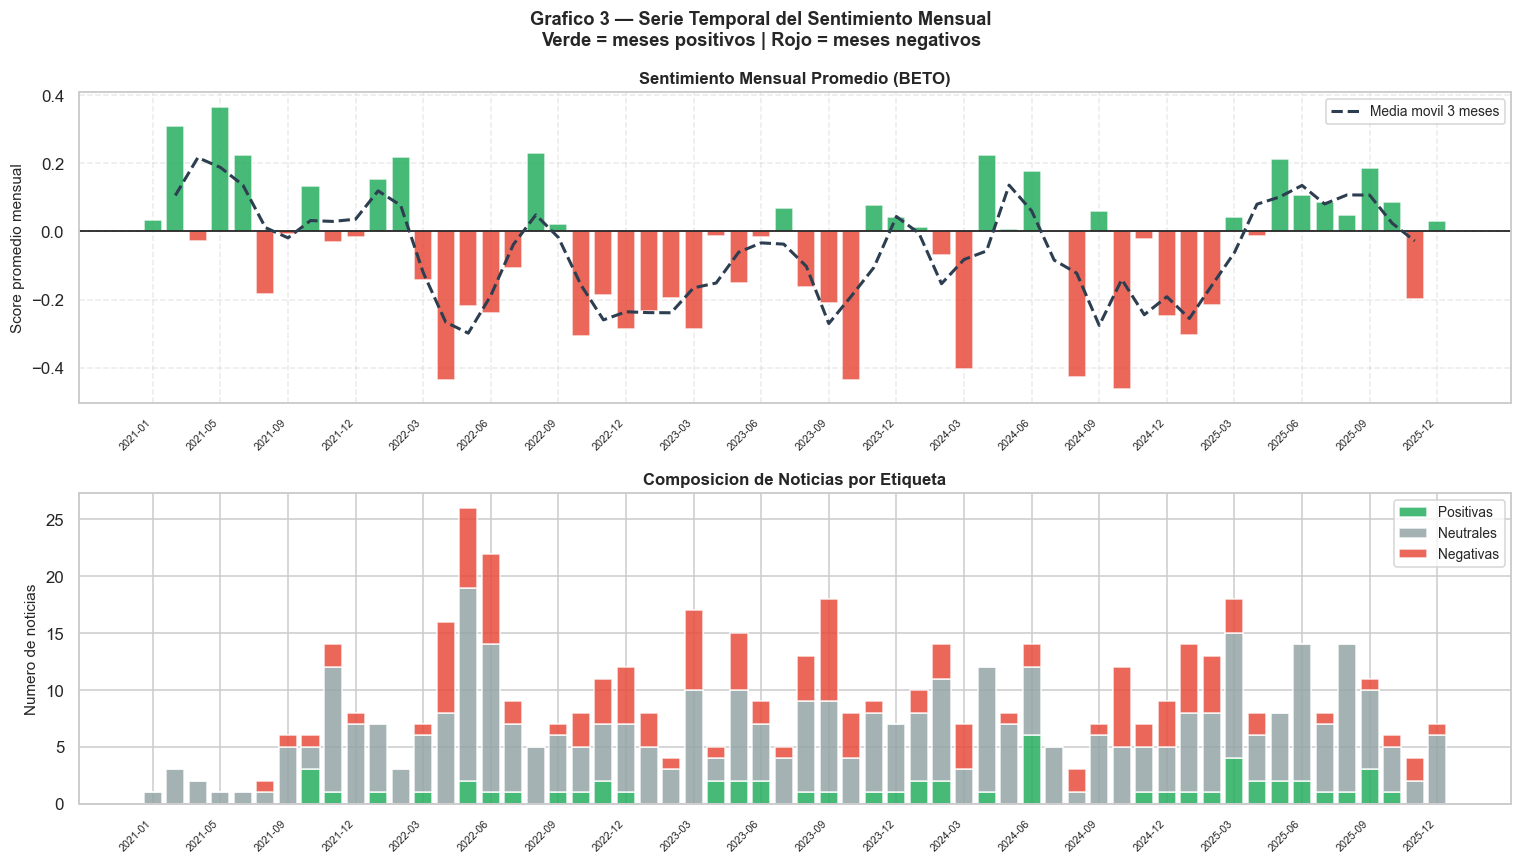

Guardado: notebooks/fase2/output/01_nlp_sentimiento/g3_serie_sentimiento_mensual.png


In [8]:
if 'sentiment_score' in df_noticias.columns:
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    # Panel 1: Score mensual
    colors_sent = ['#27ae60' if v >= 0 else '#e74c3c'
                   for v in sentimiento_mensual['avg_sentiment']]
    axes[0].bar(range(len(sentimiento_mensual)),
                sentimiento_mensual['avg_sentiment'],
                color=colors_sent, edgecolor='white', alpha=0.85)
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].plot(range(len(sentimiento_mensual)),
                 sentimiento_mensual['avg_sentiment'].rolling(3, center=True).mean(),
                 color='#2c3e50', linewidth=2, linestyle='--', label='Media movil 3 meses')
    axes[0].set_xticks(range(0, len(sentimiento_mensual), 3))
    axes[0].set_xticklabels(sentimiento_mensual['fecha_evento'].iloc[::3],
                             rotation=45, ha='right', fontsize=7)
    axes[0].set_ylabel('Score promedio mensual', fontsize=10)
    axes[0].set_title('Sentimiento Mensual Promedio (BETO)', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, linestyle='--', alpha=0.4)

    # Panel 2: Composicion por etiqueta
    axes[1].bar(range(len(sentimiento_mensual)),
                sentimiento_mensual['n_positivas'],
                color='#27ae60', edgecolor='white', alpha=0.85, label='Positivas')
    axes[1].bar(range(len(sentimiento_mensual)),
                sentimiento_mensual['n_neutrales'],
                bottom=sentimiento_mensual['n_positivas'],
                color='#95a5a6', edgecolor='white', alpha=0.85, label='Neutrales')
    axes[1].bar(range(len(sentimiento_mensual)),
                sentimiento_mensual['n_negativas'],
                bottom=sentimiento_mensual['n_positivas'] + sentimiento_mensual['n_neutrales'],
                color='#e74c3c', edgecolor='white', alpha=0.85, label='Negativas')
    axes[1].set_xticks(range(0, len(sentimiento_mensual), 3))
    axes[1].set_xticklabels(sentimiento_mensual['fecha_evento'].iloc[::3],
                             rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Numero de noticias', fontsize=10)
    axes[1].set_title('Composicion de Noticias por Etiqueta', fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9)

    plt.suptitle('Grafico 3 — Serie Temporal del Sentimiento Mensual\n'
                 'Verde = meses positivos | Rojo = meses negativos',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g3 = OUTPUT_NLP + 'g3_serie_sentimiento_mensual.png'
    plt.savefig(g3, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g3)


### Interpretacion

**Que muestra:** La evolucion mensual del sentimiento de las noticias agricolas. Los meses con score negativo (rojo) deben correlacionar con eventos adversos como el Fenomeno del Nino 2023 o caidas de precio.

**Media movil de 3 meses:** Suaviza el ruido mensual y muestra la tendencia del sentimiento a mediano plazo. Es util para identificar periodos prolongados de pessimismo o optimismo en el sector.

**Implicacion para el modelo:** El LSTM-Attention aprendera a asociar periodos de sentimiento negativo con caidas de produccion en los meses siguientes, capturando la latencia entre la percepcion del mercado y el impacto real.


---
# 6. Correlacion Sentimiento vs Produccion de Limon

Validacion de que el sentimiento tiene relacion con la produccion. Si la correlacion es significativa, justifica incluirlo en el modelo.


Correlacion de Pearson sentimiento vs produccion: 0.3199
Meses en comun: 54



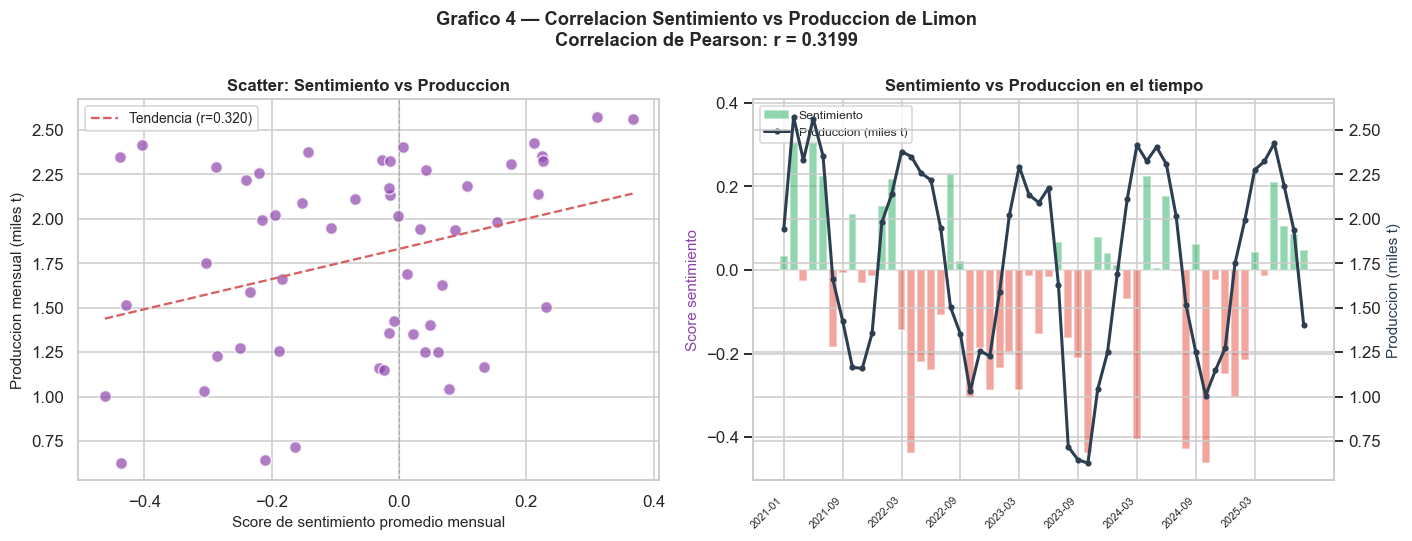

Guardado: notebooks/fase2/output/01_nlp_sentimiento/g4_correlacion_sentimiento_produccion.png


In [9]:
if 'sentiment_score' in df_noticias.columns:
    # Cargar dataset Fase 1
    df_fase1 = pd.read_csv(CONFIG['base_dataset'])
    prod_mensual = df_fase1.groupby('fecha_evento')['produccion_t'].sum().reset_index()

    # Merge con sentimiento mensual
    df_comp = pd.merge(sentimiento_mensual, prod_mensual, on='fecha_evento', how='inner')

    corr = df_comp['avg_sentiment'].corr(df_comp['produccion_t'])
    print(f'Correlacion de Pearson sentimiento vs produccion: {corr:.4f}')
    print(f'Meses en comun: {len(df_comp)}')
    print()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Scatter
    axes[0].scatter(df_comp['avg_sentiment'], df_comp['produccion_t']/1e3,
                    alpha=0.7, color='#8e44ad', edgecolors='white', s=60)
    z = np.polyfit(df_comp['avg_sentiment'], df_comp['produccion_t']/1e3, 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_comp['avg_sentiment'].min(), df_comp['avg_sentiment'].max(), 100)
    axes[0].plot(x_line, p(x_line), 'r--', linewidth=1.5, label=f'Tendencia (r={corr:.3f})')
    axes[0].axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
    axes[0].set_xlabel('Score de sentimiento promedio mensual', fontsize=10)
    axes[0].set_ylabel('Produccion mensual (miles t)', fontsize=10)
    axes[0].set_title('Scatter: Sentimiento vs Produccion', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)

    # Doble eje temporal
    ax2 = axes[1].twinx()
    axes[1].bar(range(len(df_comp)), df_comp['avg_sentiment'],
                color=['#27ae60' if v >= 0 else '#e74c3c' for v in df_comp['avg_sentiment']],
                alpha=0.5, width=0.8, label='Sentimiento')
    ax2.plot(range(len(df_comp)), df_comp['produccion_t']/1e3,
             color='#2c3e50', linewidth=2, marker='o', markersize=3,
             label='Produccion (miles t)')
    axes[1].set_xticks(range(0, len(df_comp), 6))
    axes[1].set_xticklabels(df_comp['fecha_evento'].iloc[::6],
                             rotation=45, ha='right', fontsize=7)
    axes[1].set_ylabel('Score sentimiento', fontsize=10, color='#8e44ad')
    ax2.set_ylabel('Produccion (miles t)', fontsize=10, color='#2c3e50')
    axes[1].set_title('Sentimiento vs Produccion en el tiempo', fontsize=11, fontweight='bold')
    lines1, labels1 = axes[1].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[1].legend(lines1+lines2, labels1+labels2, fontsize=8, loc='upper left')

    plt.suptitle('Grafico 4 — Correlacion Sentimiento vs Produccion de Limon\n'
                 f'Correlacion de Pearson: r = {corr:.4f}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g4 = OUTPUT_NLP + 'g4_correlacion_sentimiento_produccion.png'
    plt.savefig(g4, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g4)


### Interpretacion

**Que muestra:** La relacion entre el sentimiento mensual de las noticias y la produccion de limon. Una correlacion positiva indica que meses con noticias optimistas coinciden con mayor produccion.

**Interpretacion del coeficiente:**
- |r| > 0.5: correlacion alta — el sentimiento es muy informativo
- |r| 0.3-0.5: correlacion media — el sentimiento aporta informacion util
- |r| < 0.3: correlacion baja — el sentimiento tiene poco poder predictivo directo

**Nota:** Una correlacion baja no invalida el uso del sentimiento. El LSTM-Attention puede capturar relaciones no lineales y con rezago temporal que la correlacion de Pearson no detecta.


---
# 7. Integracion del Sentimiento al Dataset Fase 1

Se hace merge del sentimiento mensual con el dataset de la Fase 1. Los meses sin noticias reciben `avg_sentiment = 0` (neutral).


In [10]:
if 'sentiment_score' in df_noticias.columns:
    # Cargar dataset Fase 1 (valores originales)
    df_fase1 = pd.read_csv(CONFIG['base_dataset'])
    n_antes = len(df_fase1)

    # Merge con sentimiento mensual
    df_con_sent = pd.merge(
        df_fase1,
        sentimiento_mensual[['fecha_evento','avg_sentiment','n_noticias_beto']],
        on='fecha_evento',
        how='left'
    )

    # Meses sin noticias -> sentimiento neutral (0)
    df_con_sent['avg_sentiment'] = df_con_sent['avg_sentiment'].fillna(0.0)
    df_con_sent['n_noticias_beto'] = df_con_sent['n_noticias_beto'].fillna(0).astype(int)

    n_despues = len(df_con_sent)
    n_meses_sin_sent = (df_con_sent['avg_sentiment'] == 0).sum()

    print(f'Dataset Fase 1: {n_antes:,} filas')
    print(f'Dataset con sentimiento: {n_despues:,} filas')
    print(f'Filas con avg_sentiment = 0 (sin noticias ese mes): {n_meses_sin_sent:,}')
    print(f'Nulos en avg_sentiment: {df_con_sent["avg_sentiment"].isnull().sum()}')
    print()
    print('Columnas del dataset con sentimiento:')
    print(df_con_sent.columns.tolist())
    print()
    display(df_con_sent[['fecha_evento','departamento','provincia',
                          'produccion_t','n_noticias','avg_sentiment']].head(8))

    # Exportar
    out_dataset = OUTPUT_NLP + 'dataset_con_sentimiento.csv'
    df_con_sent.to_csv(out_dataset, index=False, encoding='utf-8-sig')
    print(f'Exportado: {out_dataset}')
    print(f'Shape: {df_con_sent.shape}')


Dataset Fase 1: 5,880 filas
Dataset con sentimiento: 5,880 filas
Filas con avg_sentiment = 0 (sin noticias ese mes): 210
Nulos en avg_sentiment: 0

Columnas del dataset con sentimiento:
['fecha_evento', 'departamento', 'provincia', 'produccion_t', 'cosecha_ha', 'precio_chacra_kg', 'num_emergencias', 'total_afectados', 'ALLSKY_SFC_SW_DWN', 'PRECTOTCORR', 'QV2M', 'RH2M', 'T2M', 'T2M_MAX', 'T2M_MIN', 'WS2M', 'n_noticias', 'avg_sentiment', 'n_noticias_beto']



,fecha_evento,departamento,provincia,produccion_t,n_noticias,avg_sentiment
0,2021-01,AMAZONAS,BAGUA,25.70,1.0,0.0331
1,2021-02,AMAZONAS,BAGUA,38.50,0.0,0.0000
2,2021-03,AMAZONAS,BAGUA,37.80,3.0,0.3110
3,2021-04,AMAZONAS,BAGUA,32.70,2.0,-0.0273
4,2021-05,AMAZONAS,BAGUA,34.25,1.0,0.3667
5,2021-06,AMAZONAS,BAGUA,34.80,1.0,0.2246
6,2021-07,AMAZONAS,BAGUA,34.10,0.0,0.0000
7,2021-08,AMAZONAS,BAGUA,31.90,2.0,-0.1830


Exportado: notebooks/fase2/output/01_nlp_sentimiento/dataset_con_sentimiento.csv
Shape: (5880, 19)


### Interpretacion

**Que muestra:** El dataset de la Fase 1 con la nueva columna `avg_sentiment` integrada. Cada fila (mes-provincia) tiene ahora el sentimiento promedio de las noticias de ese mes.

**Estrategia de relleno:** Los meses sin noticias reciben `avg_sentiment = 0` (neutral). Esto es conservador — no asumimos que la ausencia de noticias es positiva o negativa.

**Resultado:** El dataset pasa de 17 a 18 columnas, con `avg_sentiment` como la primera variable NLP cuantificada. Las siguientes actividades agregaran las variables ciclicas, geograficas y los rezagos temporales.


## Grafico 5 — Distribucion de avg_sentiment en el Dataset Integrado


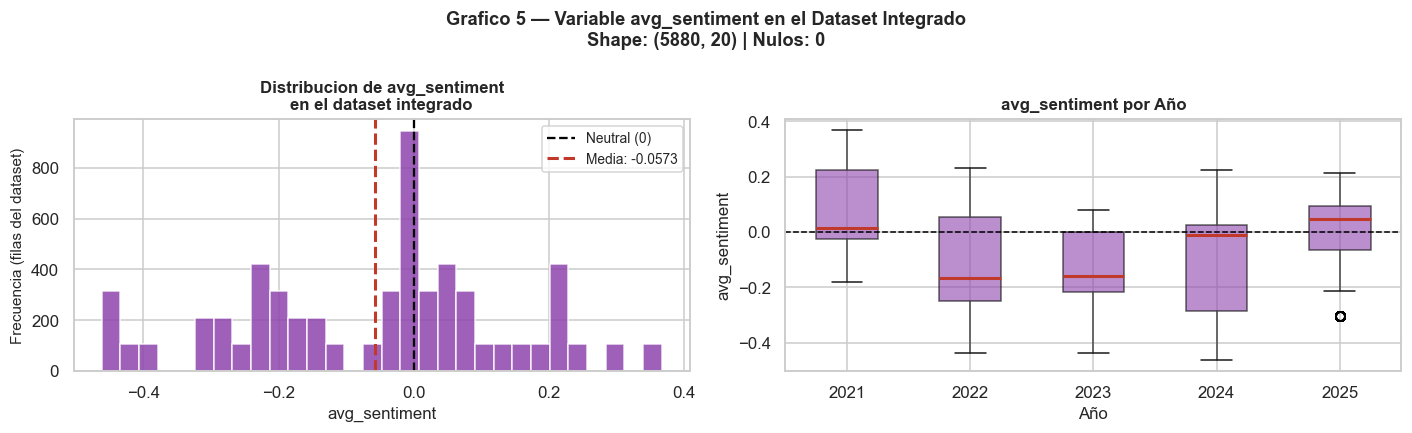

Guardado: notebooks/fase2/output/01_nlp_sentimiento/g5_avg_sentiment_dataset.png


In [11]:
if 'sentiment_score' in df_noticias.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # Histograma
    axes[0].hist(df_con_sent['avg_sentiment'], bins=30,
                 color='#8e44ad', edgecolor='white', alpha=0.85)
    axes[0].axvline(0, color='black', linestyle='--', linewidth=1.5, label='Neutral (0)')
    axes[0].axvline(df_con_sent['avg_sentiment'].mean(), color='#c0392b',
                    linestyle='--', linewidth=2,
                    label=f'Media: {df_con_sent["avg_sentiment"].mean():.4f}')
    axes[0].set_xlabel('avg_sentiment', fontsize=11)
    axes[0].set_ylabel('Frecuencia (filas del dataset)', fontsize=10)
    axes[0].set_title('Distribucion de avg_sentiment\nen el dataset integrado', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9)

    # Boxplot por año
    df_con_sent['anio'] = df_con_sent['fecha_evento'].str[:4]
    df_con_sent[df_con_sent['avg_sentiment'] != 0].boxplot(
        column='avg_sentiment', by='anio', ax=axes[1],
        patch_artist=True,
        boxprops=dict(facecolor='#8e44ad', alpha=0.6),
        medianprops=dict(color='#c0392b', linewidth=2)
    )
    axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xlabel('Año', fontsize=11)
    axes[1].set_ylabel('avg_sentiment', fontsize=11)
    axes[1].set_title('avg_sentiment por Año', fontsize=11, fontweight='bold')

    plt.suptitle('Grafico 5 — Variable avg_sentiment en el Dataset Integrado\n'
                 f'Shape: {df_con_sent.shape} | Nulos: {df_con_sent["avg_sentiment"].isnull().sum()}',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    g5 = OUTPUT_NLP + 'g5_avg_sentiment_dataset.png'
    plt.savefig(g5, dpi=120, bbox_inches='tight'); plt.show()
    print('Guardado:', g5)


### Interpretacion

**Que muestra:** La distribucion de `avg_sentiment` en el dataset integrado completo. El pico en 0 corresponde a los meses sin noticias (relleno neutral).

**Validacion:** La distribucion debe tener variabilidad suficiente para ser informativa. Si casi todos los valores son 0, el sentimiento no aportara informacion al modelo.

**Implicacion para el modelo:** La variable `avg_sentiment` esta lista para ser incluida en el dataset de la Fase 2. En la Actividad 3 se generaran sus rezagos temporales (avg_sentiment_lag1, avg_sentiment_lag3) para capturar la memoria del sentimiento del mercado.


---
# 8. Resumen de la Actividad 1


In [12]:
print('=' * 70)
print('  ACTIVIDAD 1 COMPLETADA — NLP SENTIMIENTO CON BETO')
print('=' * 70)
print()
if 'sentiment_score' in df_noticias.columns:
    print(f'Noticias procesadas: {len(df_noticias):,}')
    print(f'Score medio global: {df_noticias["sentiment_score"].mean():.4f}')
    print(f'Meses con sentimiento: {len(sentimiento_mensual)}')
    print(f'Dataset resultante: {df_con_sent.shape}')
    print(f'Nueva columna: avg_sentiment (float, rango [-1, 1])')
    print()
    print('Archivos generados:')
    import glob
    for f in sorted(glob.glob(OUTPUT_NLP + '*')):
        kb = os.path.getsize(f)//1024
        print(f'  {os.path.basename(f):<45} {kb} KB')
print()
print('Proximos pasos:')
print('  Actividad 2 -> Codificacion ciclica (month_sin, month_cos) + lat/lon')
print('  Entrada: notebooks/fase2/output/01_nlp_sentimiento/dataset_con_sentimiento.csv')


  ACTIVIDAD 1 COMPLETADA — NLP SENTIMIENTO CON BETO

Noticias procesadas: 528
Score medio global: -0.0923
Meses con sentimiento: 58
Dataset resultante: (5880, 20)
Nueva columna: avg_sentiment (float, rango [-1, 1])

Archivos generados:
  dataset_con_sentimiento.csv                   671 KB
  g1_corpus_noticias.png                        54 KB
  g3_serie_sentimiento_mensual.png              112 KB
  g4_correlacion_sentimiento_produccion.png     115 KB
  g5_avg_sentiment_dataset.png                  55 KB
  noticias_con_sentimiento.csv                  1975 KB
  sentimiento_mensual.csv                       1 KB

Proximos pasos:
  Actividad 2 -> Codificacion ciclica (month_sin, month_cos) + lat/lon
  Entrada: notebooks/fase2/output/01_nlp_sentimiento/dataset_con_sentimiento.csv
